<a href="https://colab.research.google.com/github/seop-byte/worldcup-2026-winner-prediction/blob/main/worldcup_2026_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026 FIFA World Cup Winner Prediction

## Project Goal
This project aims to predict the winning probability of national teams in the 2026 FIFA World Cup using player market values, historical World Cup records, and tournament simulation.

## Problem Definition
Since the final result of the 2026 World Cup is unknown, this project treats the prediction task as a simulation-based machine learning problem. Team strength is estimated using player market values and historical performance records, and match results are simulated based on relative team strength.

## Main Steps
1. Load player and historical World Cup data
2. Preprocess market values and positions
3. Calculate national team strength
4. Build baseline and improved strength models
5. Simulate the 2026 tournament format
6. Estimate winning probability through repeated simulations
7. Compare results across different models

## Expected Output
- Team strength ranking
- Match win probability
- World Cup tournament simulation results
- Predicted winning probability for each country

In [51]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [52]:
!pip install kagglehub

In [53]:
# 1. 필요한 라이브러리
import pandas as pd
import numpy as np
import os

# 2. 파일 업로드
from google.colab import files
uploaded = files.upload()

# 3. CSV 파일 읽기
matches = pd.read_csv("all_matches.csv")
countries = pd.read_csv("countries_names.csv")
players = pd.read_csv("players.csv")
valuations = pd.read_csv("player_valuations.csv")
rank_df = pd.read_csv("fifa_ranking-2024-06-20.csv")

# 4. 데이터 크기 확인
print("matches:", matches.shape)
print("countries:", countries.shape)
print("players:", players.shape)
print("valuations:", valuations.shape)
print("rank_df:", rank_df.shape)

# 5. 컬럼 확인
print("\n[matches columns]")
print(matches.columns.tolist())

print("\n[countries columns]")
print(countries.columns.tolist())

print("\n[players columns]")
print(players.columns.tolist())

print("\n[valuations columns]")
print(valuations.columns.tolist())

print("\n[rank_df columns]")
print(rank_df.columns.tolist())

# 6. 앞부분 확인
display(matches.head())
display(countries.head())
display(players.head())
display(valuations.head())
display(rank_df.head())

Saving all_matches.csv to all_matches (1).csv
Saving countries_names.csv to countries_names (1).csv
Saving fifa_ranking-2024-06-20.csv to fifa_ranking-2024-06-20 (1).csv
Saving player_valuations.csv to player_valuations (1).csv
Saving players.csv to players (1).csv
matches: (51492, 8)
countries: (289, 3)
players: (47669, 26)
valuations: (640176, 6)
rank_df: (67472, 8)

[matches columns]
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']

[countries columns]
['original_name', 'current_name', 'color_code']

[players columns]
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name

,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


,original_name,current_name,color_code
0,Afghanistan,Afghanistan,#AF2B34
1,Albania,Albania,#E41A13
2,Algeria,Algeria,#006233
3,Andorra,Andorra,#FFB800
4,Angola,Angola,#FF0000


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [54]:
# 날짜 형식 변환
matches["date"] = pd.to_datetime(matches["date"])
valuations["date"] = pd.to_datetime(valuations["date"])
rank_df["rank_date"] = pd.to_datetime(rank_df["rank_date"])

# countries_names.csv 기반 국가명 통일
country_map = dict(zip(countries["original_name"], countries["current_name"]))

matches["home_team"] = matches["home_team"].replace(country_map)
matches["away_team"] = matches["away_team"].replace(country_map)
matches["country"] = matches["country"].replace(country_map)
players["country_of_citizenship"] = players["country_of_citizenship"].replace(country_map)

# 추가 국가명 통일 함수
def normalize_country_name(name):
    mapping = {
        "Korea Republic": "South Korea",
        "Republic of Korea": "South Korea",
        "Korea, South": "South Korea",
        "IR Iran": "Iran",
        "Iran, Islamic Republic of": "Iran",
        "United States of America": "United States",
        "USA": "United States",
        "US": "United States",
        "Cote d'Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Czechia": "Czech Republic",
        "Türkiye": "Turkey",
        "Turkey": "Turkey",
        "China PR": "China",
        "China P.R.": "China",
        "Cape Verde Islands": "Cape Verde",
        "Curaçao": "Curacao",
        "Curacao": "Curacao",
        "Bosnia and Herzegovina": "Bosnia-Herzegovina",
        "Bosnia-Herzegovina": "Bosnia-Herzegovina",
        "Korea DPR": "North Korea",
        "DPR Korea": "North Korea"
    }
    return mapping.get(name, name)

# 모든 주요 데이터에 동일한 국가명 통일 적용
matches["home_team"] = matches["home_team"].apply(normalize_country_name)
matches["away_team"] = matches["away_team"].apply(normalize_country_name)
matches["country"] = matches["country"].apply(normalize_country_name)

players["country_of_citizenship"] = players["country_of_citizenship"].apply(normalize_country_name)

rank_df["country_full"] = rank_df["country_full"].astype(str).apply(normalize_country_name)

print("Date converted and country names normalized.")
print("FIFA ranking date range:", rank_df["rank_date"].min(), "~", rank_df["rank_date"].max())

display(matches.head())
display(players[["player_id", "name", "country_of_citizenship", "position", "sub_position"]].head())
display(rank_df.head())


# 경기 날짜 기준 가장 최근 FIFA 랭킹 붙이는 함수
def attach_rank_by_date(team_records, rank_df):
    team_records = team_records.copy()

    # team_rank 붙이기
    team_rank_list = []

    for team, group in team_records.groupby("team"):
        group = group.sort_values("date").copy()

        team_rank = rank_df[rank_df["country_full"] == team][
            ["rank_date", "rank"]
        ].sort_values("rank_date")

        if len(team_rank) == 0:
            group["team_rank"] = np.nan
        else:
            group = pd.merge_asof(
                group,
                team_rank,
                left_on="date",
                right_on="rank_date",
                direction="backward"
            )
            group = group.rename(columns={"rank": "team_rank"})
            group = group.drop(columns=["rank_date"], errors="ignore")

        team_rank_list.append(group)

    team_records = pd.concat(team_rank_list, ignore_index=True)

    # opponent_rank 붙이기
    opponent_rank_list = []

    for opponent, group in team_records.groupby("opponent"):
        group = group.sort_values("date").copy()

        opponent_rank = rank_df[rank_df["country_full"] == opponent][
            ["rank_date", "rank"]
        ].sort_values("rank_date")

        if len(opponent_rank) == 0:
            group["opponent_rank"] = np.nan
        else:
            group = pd.merge_asof(
                group,
                opponent_rank,
                left_on="date",
                right_on="rank_date",
                direction="backward"
            )
            group = group.rename(columns={"rank": "opponent_rank"})
            group = group.drop(columns=["rank_date"], errors="ignore")

        opponent_rank_list.append(group)

    team_records = pd.concat(opponent_rank_list, ignore_index=True)

    return team_records


# FIFA 랭킹 기반 가중 승점 계산 함수
# FIFA 랭킹 기반 가중 승점 계산 함수
def calculate_rank_weighted_point(row):
    team_rank = row["team_rank"]
    opponent_rank = row["opponent_rank"]
    result = row["result"]

    if pd.isna(team_rank) or pd.isna(opponent_rank):
        return np.nan

    # FIFA 랭킹은 숫자가 낮을수록 강팀
    # rank_diff > 0: 상대가 나보다 강팀
    # rank_diff < 0: 상대가 나보다 약팀
    rank_diff = team_rank - opponent_rank

    # 랭킹 차이 반영 강도
    # 기존 1.0보다 약하게 반영해서 최근 성적이 과도하게 튀는 현상을 완화
    rank_weight_strength = 1.0

    # 승리/무승부: 강팀 상대로 얻은 점수는 더 크게
    # 약팀 상대로 얻은 점수는 덜 크게
    positive_multiplier = np.clip(
        1 + rank_weight_strength * (rank_diff / 100),
        0.5,
        1.8
    )

    # 패배: 약팀에게 지면 더 크게 감점, 강팀에게 지면 덜 감점
    loss_multiplier = np.clip(
        1 - rank_weight_strength * (rank_diff / 100),
        0.5,
        1.8
    )

    if result == "W":
        return 3 * positive_multiplier
    elif result == "D":
        return 1 * positive_multiplier
    elif result == "L":
        return -3 * loss_multiplier
    else:
        return np.nan


# 국가별 월드컵 직전 경기 성적 계산 함수
def make_team_stats(matches_df, start_date, end_date, wc_year):
    period_matches = matches_df[
        (matches_df["date"] >= pd.to_datetime(start_date)) &
        (matches_df["date"] <= pd.to_datetime(end_date))
    ].copy()

    # 홈팀 기준 기록
    home = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    home = home.rename(columns={
        "home_team": "team",
        "away_team": "opponent",
        "home_score": "goals_for",
        "away_score": "goals_against"
    })

    home["result"] = np.where(
        home["goals_for"] > home["goals_against"], "W",
        np.where(home["goals_for"] == home["goals_against"], "D", "L")
    )

    # 원정팀 기준 기록
    away = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    away = away.rename(columns={
        "away_team": "team",
        "home_team": "opponent",
        "away_score": "goals_for",
        "home_score": "goals_against"
    })

    away["result"] = np.where(
        away["goals_for"] > away["goals_against"], "W",
        np.where(away["goals_for"] == away["goals_against"], "D", "L")
    )

    # 홈/원정 합치기
    team_records = pd.concat([home, away], ignore_index=True)

    # 일반 승점
    team_records["result_points"] = np.where(
        team_records["result"] == "W", 3,
        np.where(team_records["result"] == "D", 1, 0)
    )

    # FIFA 랭킹 붙이기
    team_records = attach_rank_by_date(team_records, rank_df)

    # FIFA 랭킹 기반 가중 승점
    team_records["rank_weighted_points_each"] = team_records.apply(
        calculate_rank_weighted_point,
        axis=1
    )

    # 랭킹 결측이 있는 경기는 일반 승점으로 대체
    team_records["rank_weighted_points_each"] = team_records["rank_weighted_points_each"].fillna(
        team_records["result_points"]
    )

    # 국가별 집계
    team_stats = team_records.groupby("team").agg(
        matches_played=("result", "count"),
        wins=("result", lambda x: (x == "W").sum()),
        draws=("result", lambda x: (x == "D").sum()),
        losses=("result", lambda x: (x == "L").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        points=("result_points", "sum"),
        weighted_points=("rank_weighted_points_each", "sum"),
        avg_team_rank=("team_rank", "mean"),
        avg_opponent_rank=("opponent_rank", "mean")
    ).reset_index()

    team_stats["goal_difference"] = team_stats["goals_for"] - team_stats["goals_against"]
    team_stats["win_rate"] = team_stats["wins"] / team_stats["matches_played"]
    team_stats["points_per_match"] = team_stats["points"] / team_stats["matches_played"]

    team_stats["weighted_points_per_match"] = (
        team_stats["weighted_points"] / team_stats["matches_played"]
    )

    team_stats["avg_opponent_strength"] = 1 / team_stats["avg_opponent_rank"]

    team_stats["goals_for_per_match"] = team_stats["goals_for"] / team_stats["matches_played"]
    team_stats["goals_against_per_match"] = team_stats["goals_against"] / team_stats["matches_played"]

    team_stats["world_cup_year"] = wc_year

    return team_stats

Date converted and country names normalized.
FIFA ranking date range: 1992-12-31 00:00:00 ~ 2024-06-20 00:00:00


,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


,player_id,name,country_of_citizenship,position,sub_position
0,10,Miroslav Klose,Germany,Attack,Centre-Forward
1,26,Roman Weidenfeller,Germany,Goalkeeper,Goalkeeper
2,65,Dimitar Berbatov,Bulgaria,Attack,Centre-Forward
3,77,Lúcio,Brazil,Defender,Centre-Back
4,80,Tom Starke,Germany,Goalkeeper,Goalkeeper


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [55]:
# 월드컵 기준 직전 기간 설정
# 각 월드컵 시작 전까지의 A매치 성적을 feature로 사용

world_cup_periods = {
    2006: ("2002-07-01", "2006-06-08"),
    2010: ("2006-07-10", "2010-06-10"),
    2014: ("2010-07-12", "2014-06-11"),
    2018: ("2014-07-14", "2018-06-13"),
    2022: ("2018-07-16", "2022-11-19")
}

In [56]:
# 5개 월드컵에 대해 국가별 직전 4년 성적 계산

all_team_stats = []

for wc_year, (start_date, end_date) in world_cup_periods.items():
    temp = make_team_stats(matches, start_date, end_date, wc_year)
    all_team_stats.append(temp)

all_team_stats = pd.concat(all_team_stats, ignore_index=True)

print("전체 국가-월드컵 성적 데이터 크기:", all_team_stats.shape)
display(all_team_stats.head(20))

전체 국가-월드컵 성적 데이터 크기: (1121, 19)


,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,avg_team_rank,avg_opponent_rank,goal_difference,win_rate,points_per_match,weighted_points_per_match,avg_opponent_strength,goals_for_per_match,goals_against_per_match,world_cup_year
0,Afghanistan,14,2,2,10,8,44,8,-1.80,196.545455,146.833333,-36,0.142857,0.571429,-0.128571,0.006810,0.571429,3.142857,2006
1,Albania,34,12,5,17,43,54,41,12.47,90.558824,62.000000,-11,0.352941,1.205882,0.366765,0.016129,1.264706,1.588235,2006
2,Algeria,43,14,15,14,49,51,57,8.03,69.116279,82.023810,-2,0.325581,1.325581,0.186744,0.012192,1.139535,1.186047,2006
3,American Samoa,4,0,0,4,1,34,0,-7.83,203.000000,167.250000,-33,0.000000,0.000000,-1.957500,0.005979,0.250000,8.500000,2006
4,Andorra,25,1,3,21,5,65,6,-24.89,140.760000,46.040000,-60,0.040000,0.240000,-0.995600,0.021720,0.200000,2.600000,2006
5,Angola,47,19,14,14,61,50,71,27.48,73.191489,78.325581,11,0.404255,1.510638,0.584681,0.012767,1.297872,1.063830,2006
6,Anguilla,4,0,1,3,1,10,1,-2.98,197.250000,169.333333,-9,0.000000,0.250000,-0.745000,0.005906,0.250000,2.500000,2006
7,Antigua and Barbuda,19,5,2,12,21,37,17,3.32,160.368421,111.666667,-16,0.263158,0.894737,0.174737,0.008955,1.105263,1.947368,2006
8,Argentina,50,30,10,10,94,55,100,34.56,4.980000,36.820000,39,0.600000,2.000000,0.691200,0.027159,1.880000,1.100000,2006
9,Armenia,29,6,4,19,23,55,22,-7.08,114.413793,58.655172,-32,0.206897,0.758621,-0.244138,0.017049,0.793103,1.896552,2006


In [57]:
# 월드컵 연도별 국가 수 확인

display(
    all_team_stats.groupby("world_cup_year")["team"]
    .nunique()
    .reset_index(name="num_teams")
)

,world_cup_year,num_teams
0,2006,225
1,2010,221
2,2014,228
3,2018,224
4,2022,223


In [58]:
# 월드컵별 시장가치 기준일
# 각 월드컵 시작 전날 또는 시작 직전 날짜를 기준으로 잡음

wc_cutoff_dates = {
    2006: "2006-06-08",
    2010: "2010-06-10",
    2014: "2014-06-11",
    2018: "2018-06-13",
    2022: "2022-11-19"
}
# 선수 데이터와 시장가치 데이터 합치기
player_value_data = valuations.merge(
    players[["player_id", "name", "country_of_citizenship", "position", "sub_position"]],
    on="player_id",
    how="left"
)

# 확인
print(player_value_data.shape)
display(player_value_data.head())

(640176, 10)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id,name,country_of_citizenship,position,sub_position
0,405973,2000-01-20,150000,Unknown,3057,BE1,Fadel Gobitaka,Togo,Attack,Left Winger
1,342216,2001-07-20,100000,Unknown,1241,SC1,Julien Serrano,France,Defender,Left-Back
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1,Florin Cernat,Romania,Midfield,Attacking Midfield
3,6893,2003-12-15,900000,Galatasaray,984,GB1,Gabriel Tamas,Romania,Defender,Centre-Back
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1,Miroslav Klose,Germany,Attack,Centre-Forward


In [59]:
# 포지션을 단순화하는 함수

def position_group(position):
    if position == "Goalkeeper":
        return "GK"
    elif position == "Defender":
        return "DF"
    elif position == "Midfield":
        return "MF"
    elif position == "Attack":
        return "FW"
    else:
        return "OTHER"

player_value_data["position_group"] = player_value_data["position"].apply(position_group)

display(player_value_data[["name", "country_of_citizenship", "position", "sub_position", "position_group", "market_value_in_eur", "date"]].head(20))

,name,country_of_citizenship,position,sub_position,position_group,market_value_in_eur,date
0,Fadel Gobitaka,Togo,Attack,Left Winger,FW,150000,2000-01-20
1,Julien Serrano,France,Defender,Left-Back,DF,100000,2001-07-20
2,Florin Cernat,Romania,Midfield,Attacking Midfield,MF,400000,2003-12-09
3,Gabriel Tamas,Romania,Defender,Centre-Back,DF,900000,2003-12-15
4,Miroslav Klose,Germany,Attack,Centre-Forward,FW,7000000,2004-10-04
5,Roman Weidenfeller,Germany,Goalkeeper,Goalkeeper,GK,1500000,2004-10-04
6,Dimitar Berbatov,Bulgaria,Attack,Centre-Forward,FW,8000000,2004-10-04
7,Lúcio,Brazil,Defender,Centre-Back,DF,13000000,2004-10-04
8,Tom Starke,Germany,Goalkeeper,Goalkeeper,GK,400000,2004-10-04
9,Dedê,Brazil,Defender,Left-Back,DF,9500000,2004-10-04


In [60]:
# 특정 월드컵 기준일 이전의 선수별 최신 시장가치 가져오기

def get_latest_values_before_cutoff(df, cutoff_date, wc_year):
    cutoff_date = pd.to_datetime(cutoff_date)

    temp = df[df["date"] <= cutoff_date].copy()

    # 선수별로 기준일 이전 가장 최근 시장가치만 남김
    temp = temp.sort_values(["player_id", "date"])
    latest = temp.groupby("player_id").tail(1).copy()

    latest["world_cup_year"] = wc_year

    return latest

In [61]:
# 월드컵별 국가별 베스트11 시장가치 계산
# 4-3-3, 3-4-3, 4-4-2 세 가지 포메이션을 비교하여
# 시장가치 합이 가장 높은 포메이션을 선택한다.

FORMATIONS = {
    "4-3-3": {"GK": 1, "DF": 4, "MF": 3, "FW": 3},
    "3-4-3": {"GK": 1, "DF": 5, "MF": 2, "FW": 3},
    "4-4-2": {"GK": 1, "DF": 4, "MF": 2, "FW": 4}
}


def select_best11_by_formation(group, formation):
    selected_parts = []

    for pos_group, required_num in formation.items():
        pos_players = group[group["position_group"] == pos_group].nlargest(
            required_num,
            "market_value_in_eur"
        )

        # 해당 포지션 선수가 필요한 수보다 부족하면 이 포메이션은 불완전 처리
        if len(pos_players) < required_num:
            return None

        selected_parts.append(pos_players)

    selected = pd.concat(selected_parts).drop_duplicates(subset=["player_id"])

    if len(selected) != 11:
        return None

    return selected


def calculate_best11_market_value(latest_values, wc_year):
    result_rows = []

    for country, group in latest_values.groupby("country_of_citizenship"):
        group = group.dropna(subset=["market_value_in_eur"]).copy()

        if len(group) == 0:
            continue

        best_selected = None
        best_formation_name = None
        best_total_value = -1

        for formation_name, formation in FORMATIONS.items():
            selected = select_best11_by_formation(group, formation)

            if selected is None:
                continue

            total_value = selected["market_value_in_eur"].sum()

            if total_value > best_total_value:
                best_total_value = total_value
                best_selected = selected
                best_formation_name = formation_name

        # 어떤 포메이션도 정확히 11명을 못 채우면 가능한 선수 중 시장가치 상위 11명으로 대체
        if best_selected is None:
            best_selected = group.nlargest(min(11, len(group)), "market_value_in_eur")
            best_formation_name = "fallback_top11"
            best_total_value = best_selected["market_value_in_eur"].sum()

        gk_value = best_selected[best_selected["position_group"] == "GK"]["market_value_in_eur"].sum()
        df_value = best_selected[best_selected["position_group"] == "DF"]["market_value_in_eur"].sum()
        mf_value = best_selected[best_selected["position_group"] == "MF"]["market_value_in_eur"].sum()
        fw_value = best_selected[best_selected["position_group"] == "FW"]["market_value_in_eur"].sum()

        result_rows.append({
            "team": country,
            "world_cup_year": wc_year,
            "best_formation": best_formation_name,
            "best11_market_value": best_total_value,
            "avg_best11_market_value": best_selected["market_value_in_eur"].mean(),
            "num_best11_players": len(best_selected),
            "gk_value": gk_value,
            "df_value": df_value,
            "mf_value": mf_value,
            "fw_value": fw_value
        })

    return pd.DataFrame(result_rows)


all_market_values = []

for wc_year, cutoff_date in wc_cutoff_dates.items():
    latest_values = get_latest_values_before_cutoff(player_value_data, cutoff_date, wc_year)
    market_df = calculate_best11_market_value(latest_values, wc_year)
    all_market_values.append(market_df)

all_market_values = pd.concat(all_market_values, ignore_index=True)

# 국가명 한 번 더 통일
all_market_values["team"] = all_market_values["team"].apply(normalize_country_name)

print("시장가치 데이터 크기:", all_market_values.shape)
display(all_market_values.head(20))

print("연도별 시장가치 계산 가능 국가 수:")
display(
    all_market_values.groupby("world_cup_year")["team"]
    .nunique()
    .reset_index(name="num_teams_with_market_value")
)

print("선택된 포메이션 분포:")
display(
    all_market_values.groupby(["world_cup_year", "best_formation"])
    .size()
    .reset_index(name="count")
)

시장가치 데이터 크기: (824, 10)


,team,world_cup_year,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,Albania,2006,fallback_top11,7525000,1.505000e+06,5,0,425000,3850000,3250000
1,Algeria,2006,fallback_top11,7975000,7.250000e+05,11,0,2150000,2175000,3650000
2,Angola,2006,fallback_top11,4650000,9.300000e+05,5,1000000,1100000,0,2550000
3,Antigua and Barbuda,2006,fallback_top11,300000,3.000000e+05,1,0,0,300000,0
4,Argentina,2006,4-3-3,145000000,1.318182e+07,11,6500000,46000000,51000000,41500000
5,Armenia,2006,fallback_top11,550000,2.750000e+05,2,50000,0,0,500000
6,Australia,2006,fallback_top11,6130000,7.662500e+05,8,4200000,500000,580000,850000
7,Austria,2006,4-3-3,23650000,2.150000e+06,11,1400000,10000000,8200000,4050000
8,Barbados,2006,fallback_top11,300000,3.000000e+05,1,0,300000,0,0
9,Belarus,2006,fallback_top11,12000000,2.000000e+06,6,50000,1150000,10750000,50000


연도별 시장가치 계산 가능 국가 수:


,world_cup_year,num_teams_with_market_value
0,2006,115
1,2010,155
2,2014,174
3,2018,189
4,2022,191


선택된 포메이션 분포:


,world_cup_year,best_formation,count
0,2006,3-4-3,2
1,2006,4-3-3,18
2,2006,4-4-2,7
3,2006,fallback_top11,88
4,2010,3-4-3,5
5,2010,4-3-3,43
6,2010,4-4-2,14
7,2010,fallback_top11,93
8,2014,3-4-3,8
9,2014,4-3-3,58


In [62]:
# 월드컵 본선 참가국 리스트
# 일단 시장가치 데이터가 상대적으로 충분한 2002,2006,2010, 2014, 2018, 2022 사용

world_cup_teams = {
    2006: [
        "Germany", "Costa Rica", "Poland", "Ecuador",
        "England", "Paraguay", "Trinidad and Tobago", "Sweden",
        "Argentina", "Ivory Coast", "Serbia", "Netherlands",
        "Mexico", "Iran", "Angola", "Portugal",
        "Italy", "Ghana", "United States", "Czech Republic",
        "Brazil", "Croatia", "Australia", "Japan",
        "France", "Switzerland", "South Korea", "Togo",
        "Spain", "Ukraine", "Tunisia", "Saudi Arabia"
    ],
    2010: [
        "South Africa", "Mexico", "Uruguay", "France",
        "Argentina", "Nigeria", "South Korea", "Greece",
        "England", "United States", "Algeria", "Slovenia",
        "Germany", "Australia", "Serbia", "Ghana",
        "Netherlands", "Denmark", "Japan", "Cameroon",
        "Italy", "Paraguay", "New Zealand", "Slovakia",
        "Brazil", "North Korea", "Ivory Coast", "Portugal",
        "Spain", "Switzerland", "Honduras", "Chile"
    ],
    2014: [
        "Brazil", "Croatia", "Mexico", "Cameroon",
        "Spain", "Netherlands", "Chile", "Australia",
        "Colombia", "Greece", "Ivory Coast", "Japan",
        "Uruguay", "Costa Rica", "England", "Italy",
        "Switzerland", "Ecuador", "France", "Honduras",
        "Argentina", "Bosnia-Herzegovina", "Iran", "Nigeria",
        "Germany", "Portugal", "Ghana", "United States",
        "Belgium", "Algeria", "Russia", "South Korea"
    ],
    2018: [
        "Russia", "Saudi Arabia", "Egypt", "Uruguay",
        "Portugal", "Spain", "Morocco", "Iran",
        "France", "Australia", "Peru", "Denmark",
        "Argentina", "Iceland", "Croatia", "Nigeria",
        "Brazil", "Switzerland", "Costa Rica", "Serbia",
        "Germany", "Mexico", "Sweden", "South Korea",
        "Belgium", "Panama", "Tunisia", "England",
        "Poland", "Senegal", "Colombia", "Japan"
    ],
    2022: [
        "Qatar", "Ecuador", "Senegal", "Netherlands",
        "England", "Iran", "United States", "Wales",
        "Argentina", "Saudi Arabia", "Mexico", "Poland",
        "France", "Australia", "Denmark", "Tunisia",
        "Spain", "Costa Rica", "Germany", "Japan",
        "Belgium", "Canada", "Morocco", "Croatia",
        "Brazil", "Serbia", "Switzerland", "Cameroon",
        "Portugal", "Ghana", "Uruguay", "South Korea"
    ]
}

# 참가국 리스트를 DataFrame으로 변환
wc_team_rows = []

for year, teams in world_cup_teams.items():
    for team in teams:
        wc_team_rows.append({
            "world_cup_year": year,
            "team": team
        })

wc_teams_df = pd.DataFrame(wc_team_rows)

print(wc_teams_df.shape)
display(wc_teams_df.head())

(160, 2)


,world_cup_year,team
0,2006,Germany
1,2006,Costa Rica
2,2006,Poland
3,2006,Ecuador
4,2006,England


In [63]:
# 월드컵 참가국 기준으로 경기 성적 데이터 필터링

team_stats_wc = wc_teams_df.merge(
    all_team_stats,
    on=["world_cup_year", "team"],
    how="left"
)

print("월드컵 참가국 경기 성적 데이터:", team_stats_wc.shape)
display(team_stats_wc.head(20))

# 결측치 확인
display(team_stats_wc.isnull().sum())

월드컵 참가국 경기 성적 데이터: (160, 19)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,avg_team_rank,avg_opponent_rank,goal_difference,win_rate,points_per_match,weighted_points_per_match,avg_opponent_strength,goals_for_per_match,goals_against_per_match
0,2006,Germany,52,26,14,12,107,66,92,28.68,12.076923,43.372549,41,0.500000,1.769231,0.551538,0.023056,2.057692,1.269231
1,2006,Costa Rica,61,26,11,24,89,82,89,-23.86,23.377049,57.278689,7,0.426230,1.459016,-0.391148,0.017459,1.459016,1.344262
2,2006,Poland,53,32,7,14,102,54,103,28.49,27.905660,60.980000,48,0.603774,1.943396,0.537547,0.016399,1.924528,1.018868
3,2006,Ecuador,50,17,12,21,57,69,63,-4.72,37.480000,42.860000,-12,0.340000,1.260000,-0.094400,0.023332,1.140000,1.380000
4,2006,England,42,27,8,7,83,42,89,36.91,8.523810,49.609756,41,0.642857,2.119048,0.878810,0.020157,1.976190,1.000000
5,2006,Paraguay,46,18,16,12,52,48,70,17.56,25.565217,41.456522,4,0.391304,1.521739,0.381739,0.024122,1.130435,1.043478
6,2006,Trinidad and Tobago,76,33,11,32,102,98,110,7.95,58.776316,84.349206,4,0.434211,1.447368,0.104605,0.011855,1.342105,1.289474
7,2006,Sweden,52,22,18,12,103,52,84,20.26,18.442308,52.352941,51,0.423077,1.615385,0.389615,0.019101,1.980769,1.000000
8,2006,Argentina,50,30,10,10,94,55,100,34.56,4.980000,36.820000,39,0.600000,2.000000,0.691200,0.027159,1.880000,1.100000
9,2006,Ivory Coast,36,20,8,8,62,34,68,45.43,51.222222,52.485714,28,0.555556,1.888889,1.261944,0.019053,1.722222,0.944444


,0
world_cup_year,0
team,0
matches_played,0
wins,0
draws,0
losses,0
goals_for,0
goals_against,0
points,0
weighted_points,0


In [64]:
# 월드컵 참가국 기준으로 시장가치 데이터 다시 붙이기

final_base = team_stats_wc.merge(
    all_market_values,
    on=["world_cup_year", "team"],
    how="left"
)

print("성적 + 시장가치 데이터:", final_base.shape)
display(final_base.head(20))

# 결측치 확인
display(final_base.isnull().sum())

성적 + 시장가치 데이터: (160, 27)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,...,goals_for_per_match,goals_against_per_match,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2006,Germany,52,26,14,12,107,66,92,28.68,...,2.057692,1.269231,4-4-2,92000000.0,8.363636e+06,11.0,7500000.0,25000000.0,16000000.0,43500000.0
1,2006,Costa Rica,61,26,11,24,89,82,89,-23.86,...,1.459016,1.344262,fallback_top11,1300000.0,6.500000e+05,2.0,0.0,0.0,600000.0,700000.0
2,2006,Poland,53,32,7,14,102,54,103,28.49,...,1.924528,1.018868,4-3-3,20125000.0,1.829545e+06,11.0,4500000.0,5150000.0,8450000.0,2025000.0
3,2006,Ecuador,50,17,12,21,57,69,63,-4.72,...,1.140000,1.380000,fallback_top11,2650000.0,1.325000e+06,2.0,0.0,2250000.0,0.0,400000.0
4,2006,England,42,27,8,7,83,42,89,36.91,...,1.976190,1.000000,4-3-3,261100000.0,2.373636e+07,11.0,7850000.0,85250000.0,87000000.0,81000000.0
5,2006,Paraguay,46,18,16,12,52,48,70,17.56,...,1.130435,1.043478,fallback_top11,9875000.0,1.975000e+06,5.0,0.0,50000.0,2250000.0,7575000.0
6,2006,Trinidad and Tobago,76,33,11,32,102,98,110,7.95,...,1.342105,1.289474,fallback_top11,1050000.0,5.250000e+05,2.0,0.0,0.0,0.0,1050000.0
7,2006,Sweden,52,22,18,12,103,52,84,20.26,...,1.980769,1.000000,4-3-3,59450000.0,5.404545e+06,11.0,4000000.0,11200000.0,11250000.0,33000000.0
8,2006,Argentina,50,30,10,10,94,55,100,34.56,...,1.880000,1.100000,4-3-3,145000000.0,1.318182e+07,11.0,6500000.0,46000000.0,51000000.0,41500000.0
9,2006,Ivory Coast,36,20,8,8,62,34,68,45.43,...,1.722222,0.944444,4-3-3,78250000.0,7.113636e+06,11.0,900000.0,18850000.0,18000000.0,40500000.0


,0
world_cup_year,0
team,0
matches_played,0
wins,0
draws,0
losses,0
goals_for,0
goals_against,0
points,0
weighted_points,0


In [65]:
display(final_base[[
    "world_cup_year",
    "team",
    "matches_played",
    "wins",
    "draws",
    "losses",
    "points_per_match",
    "weighted_points_per_match",
    "avg_team_rank",
    "avg_opponent_rank",
    "best_formation",
    "best11_market_value",
    "gk_value",
    "df_value",
    "mf_value",
    "fw_value"
]].head(20))

,world_cup_year,team,matches_played,wins,draws,losses,points_per_match,weighted_points_per_match,avg_team_rank,avg_opponent_rank,best_formation,best11_market_value,gk_value,df_value,mf_value,fw_value
0,2006,Germany,52,26,14,12,1.769231,0.551538,12.076923,43.372549,4-4-2,92000000.0,7500000.0,25000000.0,16000000.0,43500000.0
1,2006,Costa Rica,61,26,11,24,1.459016,-0.391148,23.377049,57.278689,fallback_top11,1300000.0,0.0,0.0,600000.0,700000.0
2,2006,Poland,53,32,7,14,1.943396,0.537547,27.905660,60.980000,4-3-3,20125000.0,4500000.0,5150000.0,8450000.0,2025000.0
3,2006,Ecuador,50,17,12,21,1.260000,-0.094400,37.480000,42.860000,fallback_top11,2650000.0,0.0,2250000.0,0.0,400000.0
4,2006,England,42,27,8,7,2.119048,0.878810,8.523810,49.609756,4-3-3,261100000.0,7850000.0,85250000.0,87000000.0,81000000.0
5,2006,Paraguay,46,18,16,12,1.521739,0.381739,25.565217,41.456522,fallback_top11,9875000.0,0.0,50000.0,2250000.0,7575000.0
6,2006,Trinidad and Tobago,76,33,11,32,1.447368,0.104605,58.776316,84.349206,fallback_top11,1050000.0,0.0,0.0,0.0,1050000.0
7,2006,Sweden,52,22,18,12,1.615385,0.389615,18.442308,52.352941,4-3-3,59450000.0,4000000.0,11200000.0,11250000.0,33000000.0
8,2006,Argentina,50,30,10,10,2.000000,0.691200,4.980000,36.820000,4-3-3,145000000.0,6500000.0,46000000.0,51000000.0,41500000.0
9,2006,Ivory Coast,36,20,8,8,1.888889,1.261944,51.222222,52.485714,4-3-3,78250000.0,900000.0,18850000.0,18000000.0,40500000.0


In [66]:
# 월드컵 실제 성적 label 만들기
# stage_score는 숫자가 클수록 좋은 성적
# 0: 조별리그 탈락
# 1: 16강
# 2: 8강
# 3: 4강
# 4: 준우승
# 5: 우승

world_cup_results = {
    2006: {
        "champion": ["Italy"],
        "runner_up": ["France"],
        "semi_final": ["Germany", "Portugal"],
        "quarter_final": ["Argentina", "England", "Ukraine", "Brazil"],
        "round_of_16": ["Ecuador", "Sweden", "Mexico", "Netherlands",
                        "Australia", "Switzerland", "Spain", "Ghana"]
    },
    2010: {
        "champion": ["Spain"],
        "runner_up": ["Netherlands"],
        "semi_final": ["Germany", "Uruguay"],
        "quarter_final": ["Argentina", "Brazil", "Ghana", "Paraguay"],
        "round_of_16": ["South Korea", "United States", "England", "Mexico",
                        "Slovakia", "Chile", "Portugal", "Japan"]
    },
    2014: {
        "champion": ["Germany"],
        "runner_up": ["Argentina"],
        "semi_final": ["Brazil", "Netherlands"],
        "quarter_final": ["Belgium", "Colombia", "Costa Rica", "France"],
        "round_of_16": ["Chile", "Uruguay", "Nigeria", "Algeria",
                        "Switzerland", "United States", "Mexico", "Greece"]
    },
    2018: {
        "champion": ["France"],
        "runner_up": ["Croatia"],
        "semi_final": ["Belgium", "England"],
        "quarter_final": ["Uruguay", "Brazil", "Sweden", "Russia"],
        "round_of_16": ["Argentina", "Portugal", "Spain", "Denmark",
                        "Mexico", "Japan", "Switzerland", "Colombia"]
    },
    2022: {
        "champion": ["Argentina"],
        "runner_up": ["France"],
        "semi_final": ["Croatia", "Morocco"],
        "quarter_final": ["Netherlands", "Brazil", "England", "Portugal"],
        "round_of_16": ["United States", "Australia", "Poland", "Senegal",
                        "Japan", "South Korea", "Spain", "Switzerland"]
    }
}

def get_stage_score(year, team):
    result = world_cup_results.get(year, {})

    if team in result.get("champion", []):
        return 5
    elif team in result.get("runner_up", []):
        return 4
    elif team in result.get("semi_final", []):
        return 3
    elif team in result.get("quarter_final", []):
        return 2
    elif team in result.get("round_of_16", []):
        return 1
    else:
        return 0

def get_stage_name(score):
    if score == 5:
        return "Champion"
    elif score == 4:
        return "Runner-up"
    elif score == 3:
        return "Semi-final"
    elif score == 2:
        return "Quarter-final"
    elif score == 1:
        return "Round of 16"
    else:
        return "Group stage"

final_base["stage_score"] = final_base.apply(
    lambda row: get_stage_score(row["world_cup_year"], row["team"]),
    axis=1
)

final_base["stage_name"] = final_base["stage_score"].apply(get_stage_name)

display(final_base[[
    "world_cup_year", "team", "stage_name", "stage_score",
    "points_per_match", "weighted_points_per_match",
    "best11_market_value"
]].head(40))

display(final_base["stage_name"].value_counts())

,world_cup_year,team,stage_name,stage_score,points_per_match,weighted_points_per_match,best11_market_value
0,2006,Germany,Semi-final,3,1.769231,0.551538,92000000.0
1,2006,Costa Rica,Group stage,0,1.459016,-0.391148,1300000.0
2,2006,Poland,Group stage,0,1.943396,0.537547,20125000.0
3,2006,Ecuador,Round of 16,1,1.260000,-0.094400,2650000.0
4,2006,England,Quarter-final,2,2.119048,0.878810,261100000.0
5,2006,Paraguay,Group stage,0,1.521739,0.381739,9875000.0
6,2006,Trinidad and Tobago,Group stage,0,1.447368,0.104605,1050000.0
7,2006,Sweden,Round of 16,1,1.615385,0.389615,59450000.0
8,2006,Argentina,Quarter-final,2,2.000000,0.691200,145000000.0
9,2006,Ivory Coast,Group stage,0,1.888889,1.261944,78250000.0


,count
stage_name,
Group stage,80
Round of 16,40
Quarter-final,20
Semi-final,10
Champion,5
Runner-up,5


In [67]:
# 최종 ML 데이터셋 만들기
# 모델에 실제로 사용하는 feature와 target에 결측치가 있는 행만 제거한다.

print("결측치 제거 전:", final_base.shape)
print("전체 결측치:")
display(final_base.isnull().sum())

# feature_cols는 23번 셀에서 정의되므로 여기서는 먼저 임시 feature 목록 사용
temp_feature_cols = [
    "gk_value",
    "df_value",
    "mf_value",
    "fw_value",
    "avg_team_rank",
    "weighted_points_per_match",
    "goals_for_per_match",
    "goals_against_per_match"
]

ml_data = final_base.dropna(subset=temp_feature_cols + ["stage_score"]).copy()

print("결측치 제거 후:", ml_data.shape)

print("제거 후 사용 feature 결측치:")
display(ml_data[temp_feature_cols + ["stage_score"]].isnull().sum())

display(ml_data.head())

ml_data.to_csv("worldcup_ml_dataset.csv", index=False)

print("worldcup_ml_dataset.csv 저장 완료")

결측치 제거 전: (160, 29)
전체 결측치:


,0
world_cup_year,0
team,0
matches_played,0
wins,0
draws,0
losses,0
goals_for,0
goals_against,0
points,0
weighted_points,0


결측치 제거 후: (158, 29)
제거 후 사용 feature 결측치:


,0
gk_value,0
df_value,0
mf_value,0
fw_value,0
avg_team_rank,0
weighted_points_per_match,0
goals_for_per_match,0
goals_against_per_match,0
stage_score,0


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,...,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value,stage_score,stage_name
0,2006,Germany,52,26,14,12,107,66,92,28.68,...,4-4-2,92000000.0,8.363636e+06,11.0,7500000.0,25000000.0,16000000.0,43500000.0,3,Semi-final
1,2006,Costa Rica,61,26,11,24,89,82,89,-23.86,...,fallback_top11,1300000.0,6.500000e+05,2.0,0.0,0.0,600000.0,700000.0,0,Group stage
2,2006,Poland,53,32,7,14,102,54,103,28.49,...,4-3-3,20125000.0,1.829545e+06,11.0,4500000.0,5150000.0,8450000.0,2025000.0,0,Group stage
3,2006,Ecuador,50,17,12,21,57,69,63,-4.72,...,fallback_top11,2650000.0,1.325000e+06,2.0,0.0,2250000.0,0.0,400000.0,1,Round of 16
4,2006,England,42,27,8,7,83,42,89,36.91,...,4-3-3,261100000.0,2.373636e+07,11.0,7850000.0,85250000.0,87000000.0,81000000.0,2,Quarter-final


worldcup_ml_dataset.csv 저장 완료


In [68]:
# 사용할 feature와 label 설정

feature_cols = [
    "gk_value",
    "df_value",
    "mf_value",
    "fw_value",
    "avg_team_rank",
    "weighted_points_per_match",
    "goals_for_per_match",
    "goals_against_per_match"
]

target_col = "stage_score"

X = ml_data[feature_cols]
y = ml_data[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (158, 8)
y shape: (158,)


,gk_value,df_value,mf_value,fw_value,avg_team_rank,weighted_points_per_match,goals_for_per_match,goals_against_per_match
0,7500000.0,25000000.0,16000000.0,43500000.0,12.076923,0.551538,2.057692,1.269231
1,0.0,0.0,600000.0,700000.0,23.377049,-0.391148,1.459016,1.344262
2,4500000.0,5150000.0,8450000.0,2025000.0,27.905660,0.537547,1.924528,1.018868
3,0.0,2250000.0,0.0,400000.0,37.480000,-0.094400,1.140000,1.380000
4,7850000.0,85250000.0,87000000.0,81000000.0,8.523810,0.878810,1.976190,1.000000


,stage_score
0,3
1,0
2,0
3,1
4,2


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train 분포")
print(y_train.value_counts().sort_index())

print("\ny_test 분포")
print(y_test.value_counts().sort_index())

X_train: (126, 8)
X_test: (32, 8)

y_train 분포
stage_score
0    62
1    32
2    16
3     8
4     4
5     4
Name: count, dtype: int64

y_test 분포
stage_score
0    16
1     8
2     4
3     2
4     1
5     1
Name: count, dtype: int64


In [70]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")

display(results_df)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.02864e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,model,MAE,RMSE,R2
4,Gradient Boosting,0.761346,0.975797,0.424760
3,Random Forest,0.761563,0.999563,0.396398
0,Linear Regression,0.851258,1.076571,0.299810
1,Ridge Regression,0.851074,1.076922,0.299353
2,Decision Tree,0.968750,1.510381,-0.378171


In [71]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

pred = best_model.predict(X_test)

prediction_check = pd.DataFrame({
    "actual_stage_score": y_test.values,
    "predicted_stage_score": pred,
    "rounded_prediction": np.round(pred).clip(0, 5)
})

display(prediction_check.head(30))

print("Best model:", best_model_name)

,actual_stage_score,predicted_stage_score,rounded_prediction
0,4,1.584409,2.0
1,1,1.375920,1.0
2,0,1.970508,2.0
3,0,0.073549,0.0
4,0,0.147551,0.0
5,1,0.289380,0.0
6,1,1.426085,1.0
7,3,2.384821,2.0
8,0,0.796394,1.0
9,0,1.154135,1.0


Best model: Gradient Boosting


In [72]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
5,weighted_points_per_match,0.178875
0,gk_value,0.141242
3,fw_value,0.134070
6,goals_for_per_match,0.127057
1,df_value,0.124445
4,avg_team_rank,0.113416
7,goals_against_per_match,0.096625
2,mf_value,0.084270


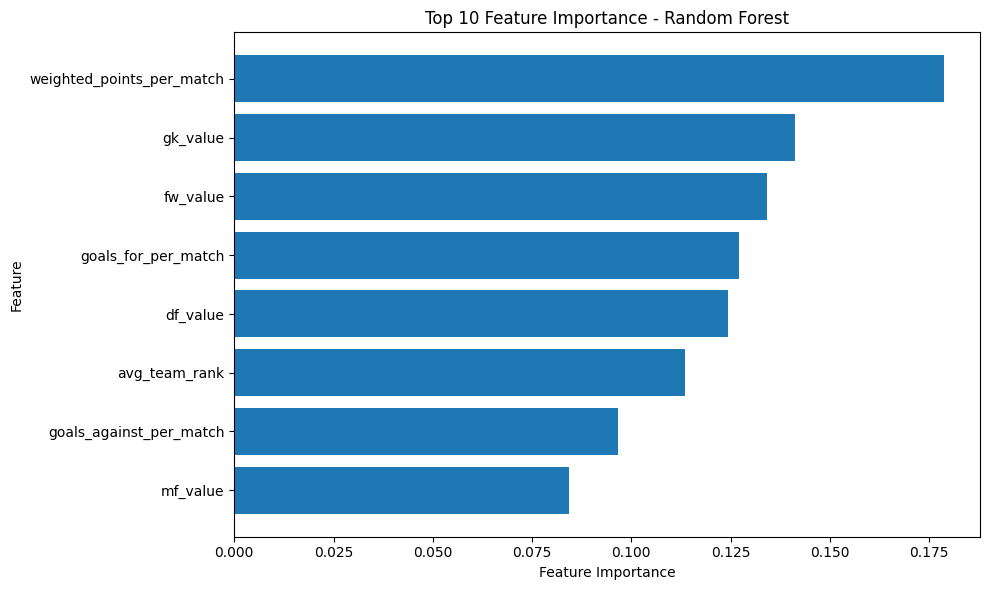

In [73]:
import matplotlib.pyplot as plt

# 상위 10개 feature importance 시각화
top_importance = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [74]:
# 결과 저장
results_df.to_csv("model_performance_results.csv", index=False)
importance_df.to_csv("feature_importance_results.csv", index=False)
ml_data.to_csv("worldcup_ml_dataset.csv", index=False)

print("저장 완료:")
print("worldcup_ml_dataset.csv")
print("model_performance_results.csv")
print("feature_importance_results.csv")

저장 완료:
worldcup_ml_dataset.csv
model_performance_results.csv
feature_importance_results.csv


In [75]:
from google.colab import files

files.download("worldcup_ml_dataset.csv")
files.download("model_performance_results.csv")
files.download("feature_importance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
display(results_df)

,model,MAE,RMSE,R2
4,Gradient Boosting,0.761346,0.975797,0.424760
3,Random Forest,0.761563,0.999563,0.396398
0,Linear Regression,0.851258,1.076571,0.299810
1,Ridge Regression,0.851074,1.076922,0.299353
2,Decision Tree,0.968750,1.510381,-0.378171


In [77]:
# 2002, 2006, 2010, 2014, 2018 데이터로 학습하고 2022 월드컵을 예측하는 구조

train_data = ml_data[ml_data["world_cup_year"].isin([2006, 2010, 2014, 2018])].copy()
test_2022 = ml_data[ml_data["world_cup_year"] == 2022].copy()

X_train_2022 = train_data[feature_cols]
y_train_2022 = train_data[target_col]

X_test_2022 = test_2022[feature_cols]
y_test_2022 = test_2022[target_col]

print("Train data:", train_data.shape)
print("Test 2022 data:", test_2022.shape)

display(test_2022[["world_cup_year", "team", "stage_name", "stage_score"]].head())

Train data: (126, 29)
Test 2022 data: (32, 29)


,world_cup_year,team,stage_name,stage_score
128,2022,Qatar,Group stage,0
129,2022,Ecuador,Group stage,0
130,2022,Senegal,Round of 16,1
131,2022,Netherlands,Quarter-final,2
132,2022,England,Quarter-final,2


In [78]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 2010, 2014, 2018 학습 데이터 내부에서 3-fold cross-validation 수행
cv = KFold(n_splits=3, shuffle=True, random_state=42)

models_params = {
    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", Ridge())
        ]),
        "params": {
            "regressor__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 5],
            "subsample": [0.8, 1.0]
        }
    }
}

tuning_results = []
best_models = {}

for name, mp in models_params.items():
    print(f"\n===== {name} tuning =====")

    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train_2022, y_train_2022)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_2022)

    mae = mean_absolute_error(y_test_2022, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_2022, y_pred))
    r2 = r2_score(y_test_2022, y_pred)

    tuning_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV RMSE": -grid.best_score_,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    })

    print("Best Params:", grid.best_params_)
    print("CV RMSE:", -grid.best_score_)
    print("Test MAE:", mae)
    print("Test RMSE:", rmse)
    print("Test R2:", r2)

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df


===== Ridge Regression tuning =====
Best Params: {'regressor__alpha': 100.0}
CV RMSE: 1.1323277910457648
Test MAE: 0.8696402093267681
Test RMSE: 1.1407499094489757
Test R2: 0.2138396433925458

===== Random Forest tuning =====
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
CV RMSE: 1.2123958459064206
Test MAE: 0.9059011047458948
Test RMSE: 1.130101740019243
Test R2: 0.22844775137369377

===== Gradient Boosting tuning =====
Best Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
CV RMSE: 1.2078911963869308
Test MAE: 0.8188759457369301
Test RMSE: 1.0691131268761966
Test R2: 0.3094779072965105


,Model,Best Params,CV RMSE,Test MAE,Test RMSE,Test R2
0,Ridge Regression,{'regressor__alpha': 100.0},1.132328,0.869640,1.140750,0.213840
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",1.212396,0.905901,1.130102,0.228448
2,Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",1.207891,0.818876,1.069113,0.309478


In [102]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================
# Baseline 1: Mean Predictor
# =========================
# 학습 데이터의 평균 stage_score를 모든 2022 테스트 국가에 동일하게 예측하는 단순 baseline

baseline_pred = np.full_like(y_test_2022, fill_value=y_train_2022.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test_2022, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_2022, baseline_pred))
baseline_r2 = r2_score(y_test_2022, baseline_pred)

models_2022 = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results_2022 = []

# baseline 결과 먼저 추가
results_2022.append({
    "model": "Mean Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

# 머신러닝 모델 성능 평가
for name, model in models_2022.items():
    model.fit(X_train_2022, y_train_2022)
    pred = model.predict(X_test_2022)

    mae = mean_absolute_error(y_test_2022, pred)
    rmse = np.sqrt(mean_squared_error(y_test_2022, pred))
    r2 = r2_score(y_test_2022, pred)

    results_2022.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_2022_df = pd.DataFrame(results_2022).sort_values("RMSE")

display(results_2022_df)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.11792e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,model,MAE,RMSE,R2
4,Random Forest,0.928646,1.144153,0.209141
5,Gradient Boosting,0.900690,1.144925,0.208074
2,Ridge Regression,0.914509,1.254873,0.048673
1,Linear Regression,0.916130,1.261530,0.038554
0,Mean Baseline,0.968750,1.286666,-0.000143
3,Decision Tree,1.312500,1.802776,-0.963422


In [103]:
# 가장 RMSE가 낮은 모델 선택
best_2022_model_name = results_2022_df.iloc[0]["model"]
best_2022_model = models_2022[best_2022_model_name]

# 2022 예측
pred_2022 = best_2022_model.predict(X_test_2022)

prediction_2022 = test_2022[[
    "world_cup_year",
    "team",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "avg_opponent_strength",
    "best11_market_value",
    "avg_best11_market_value"
]].copy()

prediction_2022["predicted_stage_score"] = pred_2022
prediction_2022["predicted_stage_score_rounded"] = np.round(pred_2022).clip(0, 5)

prediction_2022["predicted_rank"] = prediction_2022["predicted_stage_score"].rank(
    ascending=False,
    method="first"
).astype(int)

prediction_2022 = prediction_2022.sort_values("predicted_stage_score", ascending=False)

print("Best model for 2022 prediction:", best_2022_model_name)
display(prediction_2022)

Best model for 2022 prediction: Random Forest


,world_cup_year,team,stage_name,stage_score,points_per_match,weighted_points_per_match,avg_opponent_strength,best11_market_value,avg_best11_market_value,predicted_stage_score,predicted_stage_score_rounded,predicted_rank
152,2022,Brazil,Quarter-final,2,2.420000,1.516400,0.030211,745000000.0,6.772727e+07,3.273333,3.0,1
140,2022,France,Runner-up,4,2.142857,1.042653,0.023005,755000000.0,6.863636e+07,2.560000,3.0,2
144,2022,Spain,Round of 16,1,2.098039,1.187451,0.024496,633000000.0,5.754545e+07,2.473333,2.0,3
131,2022,Netherlands,Quarter-final,2,2.104167,1.205625,0.023380,433000000.0,3.936364e+07,2.470000,2.0,4
148,2022,Belgium,Group stage,0,2.240000,0.967600,0.021895,407000000.0,3.700000e+07,2.430000,2.0,5
136,2022,Argentina,Champion,5,2.240000,1.401200,0.026553,440000000.0,4.000000e+07,2.416667,2.0,6
132,2022,England,Quarter-final,2,2.137255,0.986275,0.023288,805000000.0,7.318182e+07,2.400000,2.0,7
156,2022,Portugal,Quarter-final,2,2.081633,1.069592,0.025228,675000000.0,6.136364e+07,2.286667,2.0,8
146,2022,Germany,Group stage,0,1.897959,0.869388,0.023456,619000000.0,5.627273e+07,1.913333,2.0,9
142,2022,Denmark,Group stage,0,2.040000,0.875200,0.019271,246500000.0,2.240909e+07,1.700000,2.0,10


In [104]:
top10_2022 = prediction_2022.head(10).copy()

display(top10_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "best11_market_value"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score,points_per_match,weighted_points_per_match,best11_market_value
152,1,Brazil,3.273333,3.0,Quarter-final,2,2.420000,1.516400,745000000.0
140,2,France,2.560000,3.0,Runner-up,4,2.142857,1.042653,755000000.0
144,3,Spain,2.473333,2.0,Round of 16,1,2.098039,1.187451,633000000.0
131,4,Netherlands,2.470000,2.0,Quarter-final,2,2.104167,1.205625,433000000.0
148,5,Belgium,2.430000,2.0,Group stage,0,2.240000,0.967600,407000000.0
136,6,Argentina,2.416667,2.0,Champion,5,2.240000,1.401200,440000000.0
132,7,England,2.400000,2.0,Quarter-final,2,2.137255,0.986275,805000000.0
156,8,Portugal,2.286667,2.0,Quarter-final,2,2.081633,1.069592,675000000.0
146,9,Germany,1.913333,2.0,Group stage,0,1.897959,0.869388,619000000.0
142,10,Denmark,1.700000,2.0,Group stage,0,2.040000,0.875200,246500000.0


In [101]:
results_2022_df.to_csv("model_performance_2022_prediction.csv", index=False)
prediction_2022.to_csv("country_prediction_2022.csv", index=False)
top10_2022.to_csv("top10_2022_prediction.csv", index=False)

print("저장 완료:")
print("model_performance_2022_prediction.csv")
print("country_prediction_2022.csv")
print("top10_2022_prediction.csv")

저장 완료:
model_performance_2022_prediction.csv
country_prediction_2022.csv
top10_2022_prediction.csv


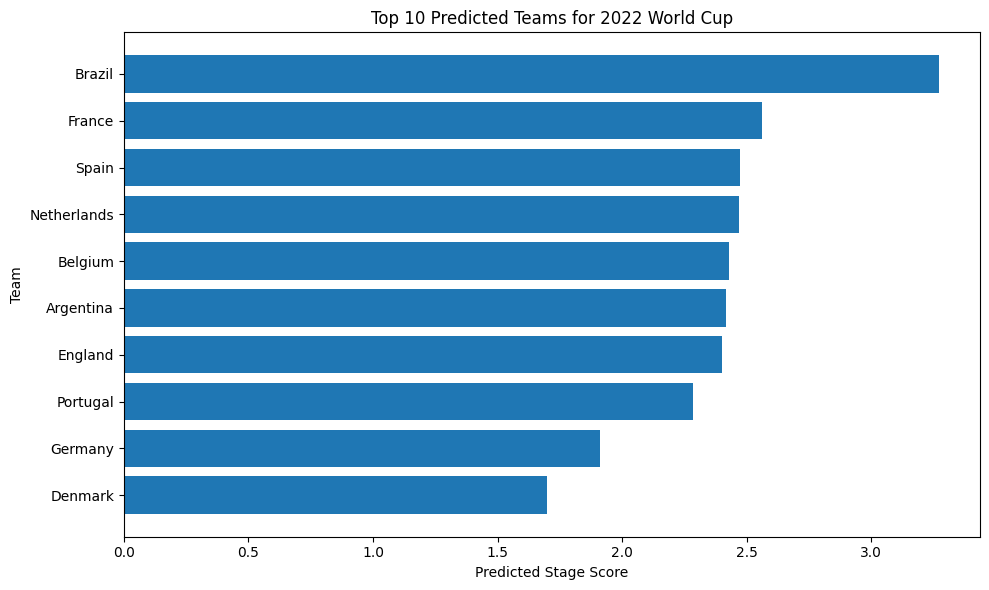

In [83]:
import matplotlib.pyplot as plt

plot_data = prediction_2022.head(10).sort_values("predicted_stage_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["team"], plot_data["predicted_stage_score"])
plt.xlabel("Predicted Stage Score")
plt.ylabel("Team")
plt.title("Top 10 Predicted Teams for 2022 World Cup")
plt.tight_layout()
plt.show()

In [84]:
# 2022 예측 결과 상위 10개 + 실제 성적 비교표

top10_2022 = prediction_2022.head(10).copy()

display(top10_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "avg_opponent_strength",
    "best11_market_value"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score,points_per_match,weighted_points_per_match,avg_opponent_strength,best11_market_value
152,1,Brazil,3.273333,3.0,Quarter-final,2,2.420000,1.516400,0.030211,745000000.0
140,2,France,2.560000,3.0,Runner-up,4,2.142857,1.042653,0.023005,755000000.0
144,3,Spain,2.473333,2.0,Round of 16,1,2.098039,1.187451,0.024496,633000000.0
131,4,Netherlands,2.470000,2.0,Quarter-final,2,2.104167,1.205625,0.023380,433000000.0
148,5,Belgium,2.430000,2.0,Group stage,0,2.240000,0.967600,0.021895,407000000.0
136,6,Argentina,2.416667,2.0,Champion,5,2.240000,1.401200,0.026553,440000000.0
132,7,England,2.400000,2.0,Quarter-final,2,2.137255,0.986275,0.023288,805000000.0
156,8,Portugal,2.286667,2.0,Quarter-final,2,2.081633,1.069592,0.025228,675000000.0
146,9,Germany,1.913333,2.0,Group stage,0,1.897959,0.869388,0.023456,619000000.0
142,10,Denmark,1.700000,2.0,Group stage,0,2.040000,0.875200,0.019271,246500000.0


In [85]:
# 전체 2022 예측 결과 확인

display(prediction_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score
152,1,Brazil,3.273333,3.0,Quarter-final,2
140,2,France,2.560000,3.0,Runner-up,4
144,3,Spain,2.473333,2.0,Round of 16,1
131,4,Netherlands,2.470000,2.0,Quarter-final,2
148,5,Belgium,2.430000,2.0,Group stage,0
136,6,Argentina,2.416667,2.0,Champion,5
132,7,England,2.400000,2.0,Quarter-final,2
156,8,Portugal,2.286667,2.0,Quarter-final,2
146,9,Germany,1.913333,2.0,Group stage,0
142,10,Denmark,1.700000,2.0,Group stage,0


In [86]:
# 최종 결과 저장

prediction_2022.to_csv("country_prediction_2022.csv", index=False)
top10_2022.to_csv("top10_2022_prediction.csv", index=False)
results_2022_df.to_csv("model_performance_2022_prediction.csv", index=False)
importance_df.to_csv("feature_importance_results.csv", index=False)

print("저장 완료")
print("country_prediction_2022.csv")
print("top10_2022_prediction.csv")
print("model_performance_2022_prediction.csv")
print("feature_importance_results.csv")

저장 완료
country_prediction_2022.csv
top10_2022_prediction.csv
model_performance_2022_prediction.csv
feature_importance_results.csv


In [87]:
from google.colab import files

files.download("country_prediction_2022.csv")
files.download("top10_2022_prediction.csv")
files.download("model_performance_2022_prediction.csv")
files.download("feature_importance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2026 World Cup Prediction

In [88]:
print("ml_data:", ml_data.shape)
print("feature_cols:", len(feature_cols))
print("matches:", matches.shape)
print("players:", players.shape)
print("valuations:", valuations.shape)

ml_data: (158, 29)
feature_cols: 8
matches: (51492, 8)
players: (47669, 26)
valuations: (640176, 6)


In [89]:
# 2026 World Cup Prediction
# FIFA World Cup 2026은 48개국 체제
# 여기서는 현재 확정/참가국 리스트를 기준으로 예측용 DataFrame을 만든다.
# 국가명은 기존 데이터셋의 표기와 최대한 맞춘다.

world_cup_teams_2026 = [
    # Host / CONCACAF
    "Canada", "Mexico", "United States",
    "Panama", "Haiti", "Curacao",

    # AFC
    "Japan", "South Korea", "Iran", "Australia",
    "Qatar", "Saudi Arabia", "Uzbekistan", "Jordan", "Iraq",

    # CONMEBOL
    "Argentina", "Brazil", "Ecuador", "Uruguay", "Colombia", "Paraguay",

    # CAF
    "Morocco", "Tunisia", "Egypt", "Algeria", "Ghana",
    "Cape Verde", "South Africa", "Senegal", "Ivory Coast", "DR Congo",

    # UEFA
    "England", "France", "Spain", "Portugal", "Netherlands", "Germany",
    "Belgium", "Croatia", "Switzerland", "Austria", "Norway", "Scotland",
    "Czech Republic", "Denmark", "Sweden", "Poland", "Turkey",
    "Bosnia and Herzegovina",

    # OFC
    "New Zealand"
]

print(len(world_cup_teams_2026))

wc_2026_df = pd.DataFrame({
    "world_cup_year": 2026,
    "team": world_cup_teams_2026
})

print("2026 teams:", wc_2026_df.shape)
display(wc_2026_df.head(20))

50
2026 teams: (50, 2)


,world_cup_year,team
0,2026,Canada
1,2026,Mexico
2,2026,United States
3,2026,Panama
4,2026,Haiti
5,2026,Curacao
6,2026,Japan
7,2026,South Korea
8,2026,Iran
9,2026,Australia


In [90]:
# 2026 참가국 국가명 표기 보정
# 기존 데이터셋의 국가명 표기와 맞추기 위한 처리

wc_2026_df["team"] = wc_2026_df["team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

matches["home_team"] = matches["home_team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

matches["away_team"] = matches["away_team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

players["country_of_citizenship"] = players["country_of_citizenship"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

player_value_data["country_of_citizenship"] = player_value_data["country_of_citizenship"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

print("국가명 표기 보정 완료")
display(wc_2026_df[wc_2026_df["team"].isin(["South Korea", "Iran", "Ivory Coast", "Czech Republic"])])

국가명 표기 보정 완료


,world_cup_year,team
7,2026,South Korea
8,2026,Iran
29,2026,Ivory Coast
43,2026,Czech Republic


In [91]:
# 2026 예측용 A매치 성적 기간
# 2022 월드컵 종료 다음날부터 데이터셋의 최신 날짜까지 사용

start_2026 = "2022-12-19"
end_2026 = matches["date"].max()

print("2026 feature period:", start_2026, "to", end_2026)

team_stats_2026_all = make_team_stats(
    matches_df=matches,
    start_date=start_2026,
    end_date=end_2026,
    wc_year=2026
)

team_stats_2026 = wc_2026_df.merge(
    team_stats_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 team stats:", team_stats_2026.shape)
display(team_stats_2026.head(20))

print("결측치 확인")
display(team_stats_2026.isnull().sum())

2026 feature period: 2022-12-19 to 2026-05-16 00:00:00
2026 team stats: (50, 19)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,avg_team_rank,avg_opponent_rank,goal_difference,win_rate,points_per_match,weighted_points_per_match,avg_opponent_strength,goals_for_per_match,goals_against_per_match
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,48.22,47.809524,51.390244,20.0,0.452381,1.714286,1.148095,0.019459,1.428571,0.952381
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,18.05,14.500000,51.833333,28.0,0.500000,1.777778,0.334259,0.019293,1.481481,0.962963
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,-4.59,11.442308,49.098039,41.0,0.500000,1.673077,-0.088269,0.020367,1.942308,1.153846
3,2026,Panama,52.0,27.0,11.0,14.0,83.0,61.0,92.0,38.42,46.961538,70.040816,22.0,0.519231,1.769231,0.738846,0.014277,1.596154,1.173077
4,2026,Haiti,35.0,18.0,9.0,8.0,77.0,40.0,63.0,31.55,86.771429,107.068966,37.0,0.514286,1.800000,0.901429,0.009340,2.200000,1.142857
5,2026,Curacao,32.0,12.0,10.0,10.0,55.0,39.0,46.0,19.61,87.625000,99.760000,16.0,0.375000,1.437500,0.612812,0.010024,1.718750,1.218750
6,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,46.59,17.658537,68.170732,94.0,0.756098,2.390244,1.136341,0.014669,2.951220,0.658537
7,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,27.49,23.166667,70.880952,44.0,0.547619,1.928571,0.654524,0.014108,1.928571,0.880952
8,2026,Iran,45.0,30.0,9.0,6.0,104.0,35.0,99.0,37.62,20.800000,85.195122,69.0,0.666667,2.200000,0.836000,0.011738,2.311111,0.777778
9,2026,Australia,36.0,22.0,6.0,8.0,69.0,26.0,72.0,17.38,24.333333,75.888889,43.0,0.611111,2.000000,0.482778,0.013177,1.916667,0.722222


결측치 확인


,0
world_cup_year,0
team,0
matches_played,1
wins,1
draws,1
losses,1
goals_for,1
goals_against,1
points,1
weighted_points,1


In [92]:
# 2026 시장가치 기준일
# 현재 valuations 데이터의 최신 날짜를 기준으로 사용

cutoff_2026 = valuations["date"].max()
print("2026 market value cutoff:", cutoff_2026)

latest_values_2026 = get_latest_values_before_cutoff(
    player_value_data,
    cutoff_2026,
    2026
)

market_2026_all = calculate_best11_market_value(
    latest_values_2026,
    2026
)

market_2026 = wc_2026_df.merge(
    market_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 market values:", market_2026.shape)
display(market_2026.head(20))

print("결측치 확인")
display(market_2026.isnull().sum())

2026 market value cutoff: 2026-05-18 00:00:00
2026 market values: (50, 10)


,world_cup_year,team,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,4-4-2,169500000.0,1.540909e+07,11.0,3500000.0,67000000.0,27000000.0,72000000.0
1,2026,Mexico,4-4-2,131500000.0,1.195455e+07,11.0,6500000.0,36000000.0,30000000.0,59000000.0
2,2026,United States,4-3-3,283500000.0,2.577273e+07,11.0,3500000.0,90000000.0,85000000.0,105000000.0
3,2026,Panama,3-4-3,30900000.0,2.809091e+06,11.0,650000.0,18200000.0,4750000.0,7300000.0
4,2026,Haiti,4-4-2,51650000.0,4.695455e+06,11.0,250000.0,6800000.0,19000000.0,25600000.0
5,2026,Curacao,3-4-3,19100000.0,1.736364e+06,11.0,200000.0,10600000.0,3100000.0,5200000.0
6,2026,Japan,4-4-2,196000000.0,1.781818e+07,11.0,20000000.0,46000000.0,37000000.0,93000000.0
7,2026,South Korea,4-3-3,116800000.0,1.061818e+07,11.0,1000000.0,33800000.0,42000000.0,40000000.0
8,2026,Iran,4-4-2,26300000.0,2.390909e+06,11.0,1500000.0,4000000.0,3500000.0,17300000.0
9,2026,Australia,4-3-3,49800000.0,4.527273e+06,11.0,2000000.0,25800000.0,10000000.0,12000000.0


결측치 확인


,0
world_cup_year,0
team,0
best_formation,1
best11_market_value,1
avg_best11_market_value,1
num_best11_players,1
gk_value,1
df_value,1
mf_value,1
fw_value,1


In [93]:
# 2026 예측용 feature 데이터 결합
# team_stats_2026과 market_2026_all을 결합하고,
# 모델 feature에 필요한 결측치는 학습 데이터의 중앙값으로 보정한다.

# 국가명 한 번 더 통일
wc_2026_df["team"] = wc_2026_df["team"].apply(normalize_country_name)
team_stats_2026["team"] = team_stats_2026["team"].apply(normalize_country_name)
market_2026_all["team"] = market_2026_all["team"].apply(normalize_country_name)

prediction_base_2026 = team_stats_2026.merge(
    market_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 prediction base before imputation:", prediction_base_2026.shape)
display(prediction_base_2026.head(20))

print("결측치 확인:")
display(prediction_base_2026.isnull().sum())

# 어떤 팀에 feature 결측치가 있는지 확인
missing_feature_rows = prediction_base_2026[
    prediction_base_2026[feature_cols].isnull().any(axis=1)
][["world_cup_year", "team"] + feature_cols]

print("feature 결측치가 있는 팀:")
display(missing_feature_rows)

# 2026 예측은 가능한 모든 참가국에 대해 수행하기 위해
# 모델 feature의 결측치는 학습 데이터의 중앙값으로 대체
prediction_data_2026 = prediction_base_2026.copy()

for col in feature_cols:
    median_value = ml_data[col].median()
    prediction_data_2026[col] = prediction_data_2026[col].fillna(median_value)

print("2026 prediction data after imputation:", prediction_data_2026.shape)

print("보정 후 feature 결측치:")
display(prediction_data_2026[feature_cols].isnull().sum())

display(prediction_data_2026.head(20))

2026 prediction base before imputation: (50, 27)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,...,goals_for_per_match,goals_against_per_match,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,48.22,...,1.428571,0.952381,4-4-2,169500000,1.540909e+07,11,3500000,67000000,27000000,72000000
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,18.05,...,1.481481,0.962963,4-4-2,131500000,1.195455e+07,11,6500000,36000000,30000000,59000000
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,-4.59,...,1.942308,1.153846,4-3-3,283500000,2.577273e+07,11,3500000,90000000,85000000,105000000
3,2026,Panama,52.0,27.0,11.0,14.0,83.0,61.0,92.0,38.42,...,1.596154,1.173077,3-4-3,30900000,2.809091e+06,11,650000,18200000,4750000,7300000
4,2026,Haiti,35.0,18.0,9.0,8.0,77.0,40.0,63.0,31.55,...,2.200000,1.142857,4-4-2,51650000,4.695455e+06,11,250000,6800000,19000000,25600000
5,2026,Curacao,32.0,12.0,10.0,10.0,55.0,39.0,46.0,19.61,...,1.718750,1.218750,3-4-3,19100000,1.736364e+06,11,200000,10600000,3100000,5200000
6,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,46.59,...,2.951220,0.658537,4-4-2,196000000,1.781818e+07,11,20000000,46000000,37000000,93000000
7,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,27.49,...,1.928571,0.880952,4-3-3,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000
8,2026,Iran,45.0,30.0,9.0,6.0,104.0,35.0,99.0,37.62,...,2.311111,0.777778,4-4-2,26300000,2.390909e+06,11,1500000,4000000,3500000,17300000
9,2026,Australia,36.0,22.0,6.0,8.0,69.0,26.0,72.0,17.38,...,1.916667,0.722222,4-3-3,49800000,4.527273e+06,11,2000000,25800000,10000000,12000000


결측치 확인:


,0
world_cup_year,0
team,0
matches_played,1
wins,1
draws,1
losses,1
goals_for,1
goals_against,1
points,1
weighted_points,1


feature 결측치가 있는 팀:


,world_cup_year,team,gk_value,df_value,mf_value,fw_value,avg_team_rank,weighted_points_per_match,goals_for_per_match,goals_against_per_match
26,2026,Cape Verde,2000000,32500000,6500000,14500000,NaN,1.578947,1.210526,1.026316
30,2026,DR Congo,5000000,33000000,50000000,45000000,NaN,1.909091,1.250000,0.545455
48,2026,Bosnia-Herzegovina,4500000,53000000,13200000,42000000,NaN,NaN,NaN,NaN


2026 prediction data after imputation: (50, 27)
보정 후 feature 결측치:


,0
gk_value,0
df_value,0
mf_value,0
fw_value,0
avg_team_rank,0
weighted_points_per_match,0
goals_for_per_match,0
goals_against_per_match,0


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,weighted_points,...,goals_for_per_match,goals_against_per_match,best_formation,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,48.22,...,1.428571,0.952381,4-4-2,169500000,1.540909e+07,11,3500000,67000000,27000000,72000000
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,18.05,...,1.481481,0.962963,4-4-2,131500000,1.195455e+07,11,6500000,36000000,30000000,59000000
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,-4.59,...,1.942308,1.153846,4-3-3,283500000,2.577273e+07,11,3500000,90000000,85000000,105000000
3,2026,Panama,52.0,27.0,11.0,14.0,83.0,61.0,92.0,38.42,...,1.596154,1.173077,3-4-3,30900000,2.809091e+06,11,650000,18200000,4750000,7300000
4,2026,Haiti,35.0,18.0,9.0,8.0,77.0,40.0,63.0,31.55,...,2.200000,1.142857,4-4-2,51650000,4.695455e+06,11,250000,6800000,19000000,25600000
5,2026,Curacao,32.0,12.0,10.0,10.0,55.0,39.0,46.0,19.61,...,1.718750,1.218750,3-4-3,19100000,1.736364e+06,11,200000,10600000,3100000,5200000
6,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,46.59,...,2.951220,0.658537,4-4-2,196000000,1.781818e+07,11,20000000,46000000,37000000,93000000
7,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,27.49,...,1.928571,0.880952,4-3-3,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000
8,2026,Iran,45.0,30.0,9.0,6.0,104.0,35.0,99.0,37.62,...,2.311111,0.777778,4-4-2,26300000,2.390909e+06,11,1500000,4000000,3500000,17300000
9,2026,Australia,36.0,22.0,6.0,8.0,69.0,26.0,72.0,17.38,...,1.916667,0.722222,4-3-3,49800000,4.527273e+06,11,2000000,25800000,10000000,12000000


In [94]:
# 2010~2022 전체 데이터로 학습하고 2026 예측
# 2026은 실제 결과가 없으므로 MAE/RMSE 평가는 하지 않는다.

from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

X_train_all = ml_data[feature_cols]
y_train_all = ml_data[target_col]

X_2026 = prediction_data_2026[feature_cols]

# 2022 테스트에서 가장 낮은 RMSE를 보인 튜닝된 Gradient Boosting 모델 사용
final_model_2026 = GradientBoostingRegressor(
    learning_rate=0.01,
    max_depth=2,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)

final_model_2026.fit(X_train_all, y_train_all)

pred_2026 = final_model_2026.predict(X_2026)

prediction_2026 = prediction_data_2026[[
    "world_cup_year",
    "team",
    "matches_played",
    "points_per_match",
    "weighted_points_per_match",
    "avg_team_rank",
    "avg_opponent_rank",
    "best_formation",
    "best11_market_value",
    "avg_best11_market_value",
    "gk_value",
    "df_value",
    "mf_value",
    "fw_value",
    "goals_for_per_match",
    "goals_against_per_match"
]].copy()

prediction_2026["predicted_stage_score"] = pred_2026
prediction_2026["predicted_stage_score_rounded"] = np.round(pred_2026).clip(0, 5)

prediction_2026["predicted_rank"] = prediction_2026["predicted_stage_score"].rank(
    ascending=False,
    method="first"
).astype(int)

prediction_2026 = prediction_2026.sort_values("predicted_stage_score", ascending=False)

display(prediction_2026.head(20))

,world_cup_year,team,matches_played,points_per_match,weighted_points_per_match,avg_team_rank,avg_opponent_rank,best_formation,best11_market_value,avg_best11_market_value,gk_value,df_value,mf_value,fw_value,goals_for_per_match,goals_against_per_match,predicted_stage_score,predicted_stage_score_rounded,predicted_rank
33,2026,Spain,39.0,2.435897,1.608718,8.410256,42.025641,4-3-3,930000000,8.454545e+07,40000000,260000000,330000000,300000000,2.666667,0.820513,2.170904,2.0,1
32,2026,France,38.0,2.157895,1.117105,2.052632,41.166667,4-4-2,980000000,8.909091e+07,30000000,280000000,140000000,530000000,2.236842,0.842105,1.979115,2.0,2
15,2026,Argentina,37.0,2.513514,1.127838,1.054054,52.972973,4-3-3,600000000,5.454545e+07,15000000,130000000,235000000,220000000,2.162162,0.378378,1.786411,2.0,3
34,2026,Portugal,38.0,2.236842,1.122895,6.631579,50.685714,4-3-3,687000000,6.245455e+07,40000000,220000000,260000000,167000000,2.578947,0.815789,1.781023,2.0,4
28,2026,Senegal,43.0,2.441860,1.452093,18.325581,89.756757,4-3-3,319000000,2.900000e+07,7000000,80000000,107000000,125000000,2.069767,0.441860,1.713777,2.0,5
21,2026,Morocco,48.0,2.437500,1.076042,12.166667,87.108696,4-3-3,342500000,3.113636e+07,3500000,135000000,114000000,90000000,2.020833,0.395833,1.613255,2.0,6
6,2026,Japan,41.0,2.390244,1.136341,17.658537,68.170732,4-4-2,196000000,1.781818e+07,20000000,46000000,37000000,93000000,2.951220,0.658537,1.465999,1.0,7
19,2026,Colombia,41.0,1.951220,0.986341,13.536585,33.146341,4-4-2,262500000,2.386364e+07,6500000,82000000,33000000,141000000,1.804878,0.853659,1.402542,1.0,8
16,2026,Brazil,35.0,1.571429,0.139429,3.800000,29.514286,4-4-2,722000000,6.563636e+07,17000000,200000000,120000000,385000000,1.657143,1.114286,1.370428,1.0,9
36,2026,Germany,38.0,1.842105,0.693421,15.631579,29.763158,4-3-3,665000000,6.045455e+07,20000000,175000000,305000000,165000000,2.105263,1.236842,1.282243,1.0,10


,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,points_per_match,weighted_points_per_match,best11_market_value
33,1,Spain,2.170904,2.0,2.435897,1.608718,930000000
32,2,France,1.979115,2.0,2.157895,1.117105,980000000
15,3,Argentina,1.786411,2.0,2.513514,1.127838,600000000
34,4,Portugal,1.781023,2.0,2.236842,1.122895,687000000
28,5,Senegal,1.713777,2.0,2.441860,1.452093,319000000
21,6,Morocco,1.613255,2.0,2.437500,1.076042,342500000
6,7,Japan,1.465999,1.0,2.390244,1.136341,196000000
19,8,Colombia,1.402542,1.0,1.951220,0.986341,262500000
16,9,Brazil,1.370428,1.0,1.571429,0.139429,722000000
36,10,Germany,1.282243,1.0,1.842105,0.693421,665000000


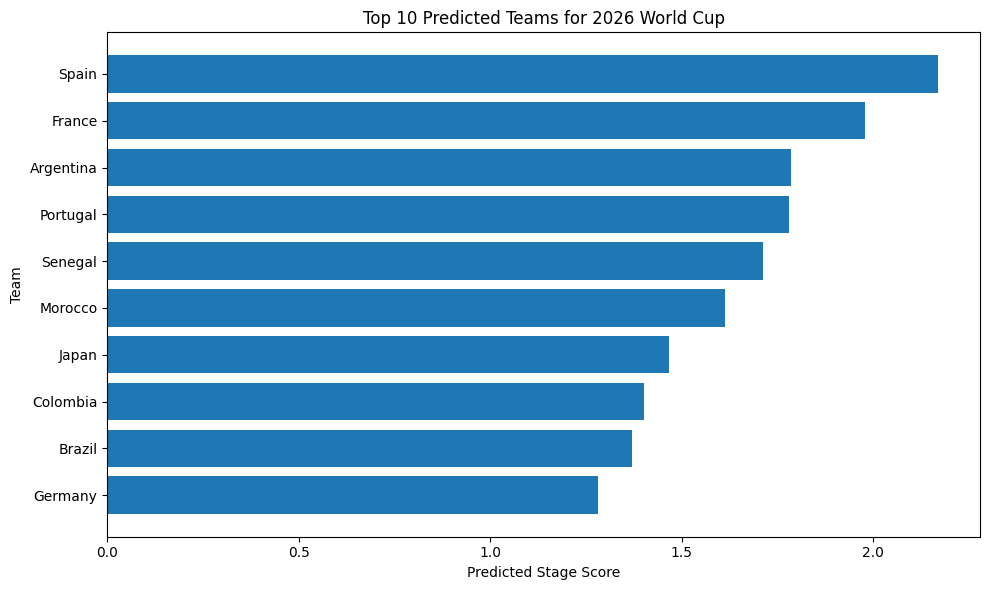

In [95]:
top10_2026 = prediction_2026.head(10).copy()

display(top10_2026[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "points_per_match",
    "weighted_points_per_match",
    "best11_market_value"
]])

import matplotlib.pyplot as plt

plot_data = top10_2026.sort_values("predicted_stage_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["team"], plot_data["predicted_stage_score"])
plt.xlabel("Predicted Stage Score")
plt.ylabel("Team")
plt.title("Top 10 Predicted Teams for 2026 World Cup")
plt.tight_layout()
plt.show()

In [96]:
prediction_2026.to_csv("country_prediction_2026.csv", index=False)
top10_2026.to_csv("top10_2026_prediction.csv", index=False)

print("저장 완료:")
print("country_prediction_2026.csv")
print("top10_2026_prediction.csv")

저장 완료:
country_prediction_2026.csv
top10_2026_prediction.csv


In [97]:
from google.colab import files

files.download("country_prediction_2026.csv")
files.download("top10_2026_prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>